In [1]:
%%capture out
!conda install -c conda-forge xgboost -y
!conda install -c conda-forge scikit-survival -y
!conda install -c conda-forge tensorflow -y
!pip install lightgbm
!pip install lifelines
!pip install seaborn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
import lightgbm as lgb
import time
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, average_precision_score, confusion_matrix
from lifelines.utils import concordance_index
from lifelines import CoxPHFitter
from sksurv.ensemble import RandomSurvivalForest
import tensorflow as tf
from tensorflow.keras import layers, models

2026-05-03 22:55:29.982760: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX512F, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
def evaluate_model(model_name, y_true, y_pred, y_prob, train_time):
    """Calculates and prints model metrics for imbalanced data."""
    pr_auc = average_precision_score(y_true, y_prob)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    conf_matrix = confusion_matrix(y_true, y_pred)

    print(f'---{model_name} Results---')
    print(f'Training Time: {train_time:.2f} seconds')
    print(f'PR-AUC: {pr_auc:.3f}')
    print(f'Precision: {precision:.3f}')
    print(f'Recall: {recall:.3f}')
    print(f'Confusion Matrix: \n{conf_matrix}\n')


def evaluate_survival_model(model_name, y_time_true, y_event_true, predicted_risk, train_time):
    """Evaluates survival models using the concordance index."""
    c_index = concordance_index(y_time_true, -predicted_risk, y_event_true)
    print(f'--- {model_name} Results ---')
    print(f'Training Time: {train_time:.2f} seconds')
    print(f'Concordance Index: {c_index:.3f}\n')


def evaluate_anomaly_model(model_name, anomaly_scores, y_test_labels, threshold_percentile=1, train_time=0):

    threshold = np.percentile(anomaly_scores, 100 - threshold_percentile)

    y_pred_anomaly = (anomaly_scores > threshold).astype(int)

    caught_failures = np.sum((y_pred_anomaly == 1) & (y_test_labels == 1))
    total_failures = np.sum(y_test_labels == 1)

    print(f"--- {model_name} Results ---")
    print(f'Training Time: {train_time:.2f} seconds')
    print(f"Top {threshold_percentile}% Anomaly Net Caught: {caught_failures} / {total_failures} actual failures.")
    print(f"Pseudo-Recall: {(caught_failures/total_failures)*100:.2f}%\n")

In [4]:
print('Loading Matrices from Disk...')
X_train = pd.read_parquet('data_ready/ml_matrices/X_train.parquet').astype({'vault_id': 'int16', 'cluster_id': 'int8'})
X_test = pd.read_parquet('data_ready/ml_matrices/X_test.parquet').astype({'vault_id': 'int16', 'cluster_id': 'int8'})
y_train = pd.read_parquet('data_ready/ml_matrices/y_train.parquet').squeeze()
y_test = pd.read_parquet('data_ready/ml_matrices/y_test.parquet').squeeze()

y_time_train = pd.read_parquet('data_ready/ml_matrices/y_time_train.parquet').squeeze()
y_event_train = pd.read_parquet('data_ready/ml_matrices/y_event_train.parquet').squeeze()
y_time_test = pd.read_parquet('data_ready/ml_matrices/y_time_test.parquet').squeeze()
y_event_test = pd.read_parquet('data_ready/ml_matrices/y_event_test.parquet').squeeze()

X_train_healthy_scaled = pd.read_parquet('data_ready/ml_matrices/X_train_healthy_scaled.parquet')
X_test_scaled = pd.read_parquet('data_ready/ml_matrices/X_test_scaled.parquet')

print(f'X_train shape: {X_train.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_test shape: {y_test.shape}')

Loading Matrices from Disk...
X_train shape: (765101, 89)
y_train shape: (765101,)
X_test shape: (155648, 89)
y_test shape: (155648,)


# Phase 1: Binary Classification (Will the drive fail?)

## Random Forest Baseline

### Random Forest builds many independent trees, it is robust to overfitting and doesn't require much hyperparameter tuning. Because of this the results from this model will get a "decent" baseline to compare other models to.

In [7]:
print('Training Random Forest Baseline...')
start_time = time.time()
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=6740, n_jobs=-1)
rf_model.fit(X_train, y_train)

rf_time = time.time() - start_time

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

evaluate_model('Random Forest', y_test, rf_pred, rf_prob, rf_time)

Training Random Forest Baseline...
---Random Forest Results---
Training Time: 94.79 seconds
PR-AUC: 0.710
Precision: 0.913
Recall: 0.532
Confusion Matrix: 
[[154655     48]
 [   442    503]]



## Gradient Boosting Comparison

### Comparing the training/testing speed, memory efficiency, and predictive ability of two types of gradient boosting models. 

#### XGBoost

In [8]:
print('Training XGBoost...')
start_time = time.time()

weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb_model = xgb.XGBClassifier(
    scale_pos_weight=weight,
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=6740,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)
xgb_time = time.time() - start_time
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]
evaluate_model('XGBoost', y_test, xgb_pred, xgb_prob, xgb_time)

Training XGBoost...
---XGBoost Results---
Training Time: 8.03 seconds
PR-AUC: 0.691
Precision: 0.156
Recall: 0.870
Confusion Matrix: 
[[150239   4464]
 [   123    822]]



#### LightGBM

In [9]:
print('Training LightGBM...')
start_time = time.time()

lgb_model = lgb.LGBMClassifier(
    class_weight='balanced',
    n_estimators=100,
    random_state=6740,
    n_jobs=-1
)

lgb_model.fit(X_train, y_train)
lgb_time = time.time() - start_time
lgb_pred = lgb_model.predict(X_test)
lgb_prob = lgb_model.predict_proba(X_test)[:, 1]
evaluate_model('LightGBM', y_test, lgb_pred, lgb_prob, lgb_time)

Training LightGBM...
[LightGBM] [Info] Number of positive: 5922, number of negative: 759179
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.080313 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9211
[LightGBM] [Info] Number of data points in the train set: 765101, number of used features: 69
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
---LightGBM Results---
Training Time: 6.11 seconds
PR-AUC: 0.703
Precision: 0.185
Recall: 0.871
Confusion Matrix: 
[[151078   3625]
 [   122    823]]



# Phase 2: Survival Analysis (When will the drive fail?)

## Cox Proportional Hazards Baseline

### Assumes a linear combination of SMART stats increases the base "hazard rate". Provides interpretable coefficients.

In [10]:
variances = X_train.var()
valid_cols = variances[variances > 0].index
X_train_cox = X_train[valid_cols].copy()
X_test_cox = X_test[valid_cols].copy()

cox_scaler = StandardScaler()
X_train_cox_scaled = pd.DataFrame(cox_scaler.fit_transform(X_train_cox), columns=X_train_cox.columns)
X_test_cox_scaled = pd.DataFrame(cox_scaler.fit_transform(X_test_cox), columns=X_test_cox.columns)

train_df_surv = X_train_cox_scaled.copy()
train_df_surv['time'] = y_time_train.reset_index(drop=True)
train_df_surv['event'] = y_event_train.reset_index(drop=True)

print('Training Cox Proportional Hazards...')
start_time = time.time()
cph = CoxPHFitter(penalizer=0.5)
cph.fit(train_df_surv, duration_col='time', event_col='event')

cph_time = time.time() - start_time
cph_risk_scores = cph.predict_partial_hazard(X_test)

evaluate_survival_model('Cox Proportional Hazards', y_time_test, y_event_test, cph_risk_scores, cph_time)

Training Cox Proportional Hazards...


/home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


--- Cox Proportional Hazards Results ---
Training Time: 30.65 seconds
Concordance Index: 0.504



## Non-Linear Survival Models

### Does not assume a linear relationship. 

In [ ]:
y_train_sksurv = np.array(
    list(zip(y_event_train.astype(bool), y_time_train)),
    dtype=[('event', '?'), ('time', '<f8')]
)
print("Training Random Survival Forest...")
start_time = time.time()
rsf = RandomSurvivalForest(
    n_estimators=50,
    min_samples_split=100,
    min_samples_leaf=50,
    max_depth=10,
    n_jobs=1,
    random_state=6740
)
rsf.fit(X_train, y_train_sksurv)
rsf_time = time.time() - start_time
rsf_risk_scores = rsf.predict(X_test)

evaluate_survival_model("Random Survival Forest", y_time_test, y_event_test, rsf_risk_scores, rsf_time)

Training Random Survival Forest...


In [8]:
y_train_xgb_surv = np.where(y_event_train == 1, y_time_train, -y_time_train)
print("Training XGBoost Survival...")
start_time = time.time()
xgb_surv = xgb.XGBRegressor(
    objective='survival:cox',
    tree_method='hist',
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    random_state=6740,
    n_jobs=-1
)
xgb_surv.fit(X_train, y_train_xgb_surv)
xgb_surv_time = time.time() - start_time
xgb_risk_scores = xgb_surv.predict(X_test)

evaluate_survival_model("XGBoost Survival", y_time_test, y_event_test, xgb_risk_scores, xgb_surv_time)

Training XGBoost Survival...
--- XGBoost Survival Results ---
Training Time: 19.83 seconds
Concordance Index: 0.976



# Phase 3: Anomaly Detection (Is this drive an outlier?)

## Isolation Forest

In [12]:
print("Training Isolation Forest...")
start_time = time.time()

iso_forest = IsolationForest(n_estimators=100, contamination='auto', random_state=42, n_jobs=-1)
iso_forest.fit(X_train_healthy_scaled)

iso_scores = -1 * iso_forest.score_samples(X_test_scaled)
iso_time = time.time() - start_time
evaluate_anomaly_model("Isolation Forest", iso_scores, y_test, train_time=iso_time)

Training Isolation Forest...
--- Isolation Forest Results ---
Training Time: 1.48 seconds
Top 1% Anomaly Net Caught: 183 / 945 actual failures.
Pseudo-Recall: 19.37%



## Autoencoder

In [13]:
print("Building Autoencoder Architecture...")
input_dim = X_train_healthy_scaled.shape[1]

autoencoder = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(input_dim, activation='linear')
])

autoencoder.compile(optimizer='adam', loss='mse')

print("Training Autoencoder (Monitoring Reconstruction Loss)...")
start_time = time.time()
history = autoencoder.fit(
    X_train_healthy_scaled, X_train_healthy_scaled,
    epochs=20,
    batch_size=256,
    validation_split=0.1,
    verbose=1
)

print("\nCalculating Reconstruction Errors on Test Set...")
reconstructions = autoencoder.predict(X_test_scaled)

autoencoder_scores = np.mean(np.square(X_test_scaled - reconstructions), axis=1)
auto_time = time.time() - start_time
evaluate_anomaly_model("Deep Learning Autoencoder", autoencoder_scores, y_test, train_time=auto_time)

Building Autoencoder Architecture...
Training Autoencoder (Monitoring Reconstruction Loss)...
Epoch 1/20
2669/2669 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 0.4389 - val_loss: 0.2937
Epoch 2/20
2669/2669 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.2942 - val_loss: 0.2427
Epoch 3/20
2669/2669 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.2435 - val_loss: 0.2370
Epoch 4/20
2669/2669 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.2170 - val_loss: 0.1962
Epoch 5/20
2669/2669 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.1852 - val_loss: 0.2199
Epoch 6/20
2669/2669 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 0.1569 - val_loss: 0.2038
Epoch 7/20
2669/2669 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.1626 - val_loss: 0.2066
Epoch 8/20
2669/2669 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.1323 - val_loss: 0.1800
Epoch 9/20
2669/2669 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.1256 - val_loss: 0.1769
Epoch 10/20
2669/2669 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.1340 - val_loss: 0.1585
Epoch 11/20
2669/2669 ━━

Generating Feature Importance Chart...


/tmp/ipykernel_28953/1263188493.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_features, x='Importance', y='Feature', palette='viridis')


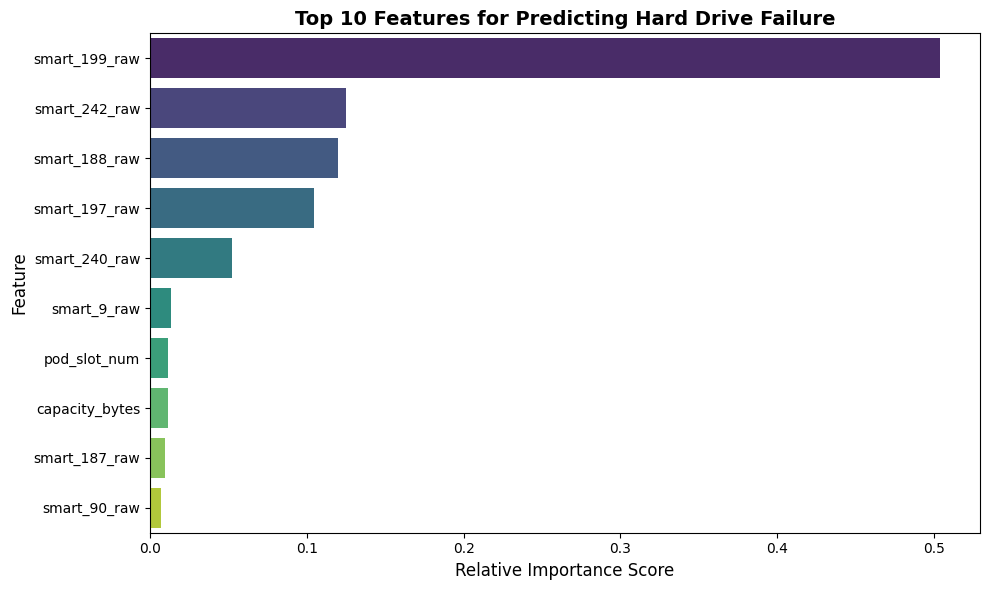

In [9]:
print("Generating Feature Importance Chart...")

importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_surv.feature_importances_
}).sort_values(by='Importance', ascending=False)

top_10_features = importance_df.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_10_features, x='Importance', y='Feature', palette='viridis')

plt.title('Top 10 Features for Predicting Hard Drive Failure', fontsize=14, fontweight='bold')
plt.xlabel('Relative Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)

plt.tight_layout()
plt.show()

Generating Autoencoder Anomaly Distribution...


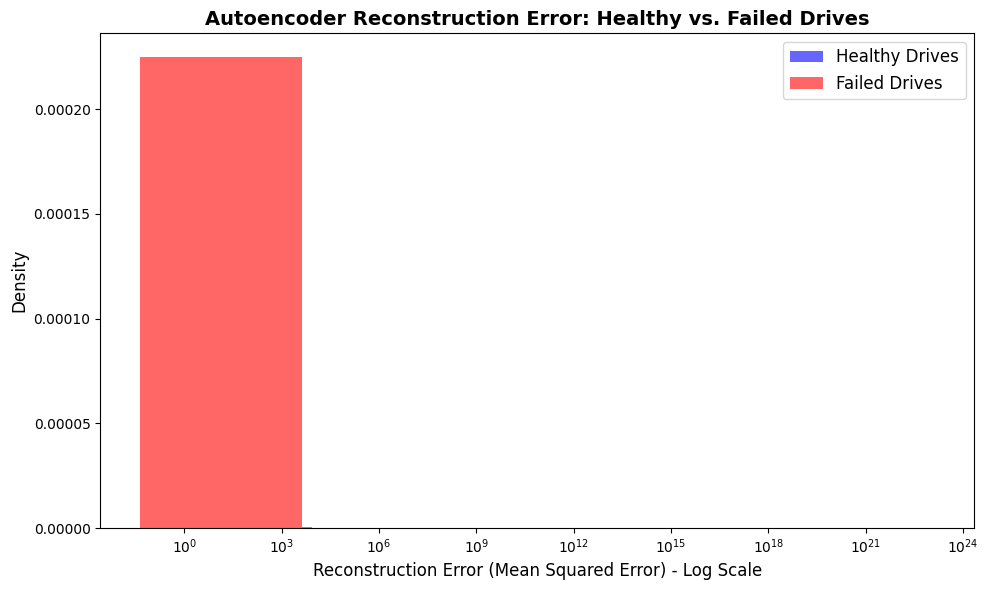

In [19]:
print("Generating Autoencoder Anomaly Distribution...")

healthy_scores = autoencoder_scores[y_test == 0]
failed_scores = autoencoder_scores[y_test == 1]

plt.figure(figsize=(10, 6))

plt.hist(healthy_scores, bins=50, alpha=0.6, color='blue', label='Healthy Drives', density=True)
plt.hist(failed_scores, bins=50, alpha=0.6, color='red', label='Failed Drives', density=True)

plt.xscale('log') 

plt.title('Autoencoder Reconstruction Error: Healthy vs. Failed Drives', fontsize=14, fontweight='bold')
plt.xlabel('Reconstruction Error (Mean Squared Error) - Log Scale', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()

In [6]:
print("Generating Master Performance Table...")

results_data = {
    'Phase': [
        'Phase 1 (Binary)',
        'Phase 2 (Survival)',
        'Phase 2 (Survival)',
        'Phase 3 (Anomaly)',
        'Phase 3 (Anomaly)'
    ],
    'Algorithm': [
        'XGBoost Classifier',
        'Cox Proportional Hazards',
        'Random Survival Forest',
        'Isolation Forest',
        'Deep Autoencoder'
    ],
    'Primary Metric': [
        'PR-AUC: 0.691',
        'C-Index: 0.504',
        'C-Index: 0.672',
        'Top 1% Caught: 19.37%',
        'Top 1% Caught: 31.64%'
    ],
    'Training Time': [
        '8.21s',
        '35.36s',
        '3045.47s',
        '1.48s',
        '161.36s'
    ]
}

results_df = pd.DataFrame(results_data)

results_df = results_df.set_index('Phase')

display(results_df)

Generating Master Performance Table...


,Algorithm,Primary Metric,Training Time
Phase,,,
Phase 1 (Binary),XGBoost Classifier,PR-AUC: 0.691,8.21s
Phase 2 (Survival),Cox Proportional Hazards,C-Index: 0.504,35.36s
Phase 2 (Survival),Random Survival Forest,C-Index: 0.672,3045.47s
Phase 3 (Anomaly),Isolation Forest,Top 1% Caught: 19.37%,1.48s
Phase 3 (Anomaly),Deep Autoencoder,Top 1% Caught: 31.64%,161.36s
